In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
base_dir = '../../../../datos-notebooks/1.global-data-cba/'
ground_data_name = 'reflective-objects.csv'
ground_data_path = os.path.join(base_dir, 'MRT-prediction/ground_data', ground_data_name)

In [4]:
df = pd.read_csv(ground_data_path, sep=";")
df

,meters to wall,TA1,TG1,WIND1,MRT 1,TA2,TG2,WIND 2,MRT 2,MRT AVG
0,1,29.5,45.0,0.2,62.7,29.9,41.7,0.20,55.8,59.3
1,3,28.1,42.0,0.2,58.4,28.3,40.1,0.20,54.4,56.4
2,5,26.1,41.3,0.2,59.2,28.5,41.0,0.17,54.7,57.0
3,7,26.0,39.9,0.2,56.6,29.0,40.2,0.20,53.8,55.2
4,9,25.6,40.4,0.2,58.0,27.9,38.1,0.30,54.1,56.0
5,11,28.0,40.3,0.2,55.2,NaN,NaN,NaN,NaN,NaN
6,13,27.8,39.7,0.2,54.2,NaN,NaN,NaN,NaN,NaN


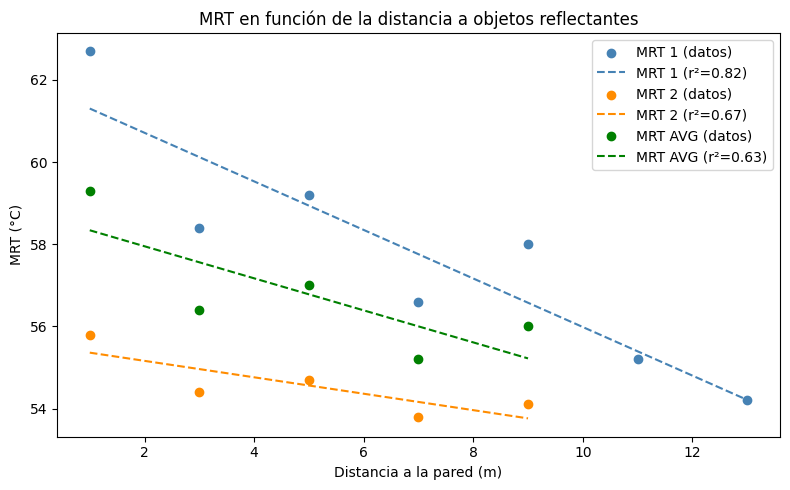

In [5]:
from scipy import stats

fig, ax = plt.subplots(figsize=(8, 5))

colors = {"MRT 1": "steelblue", "MRT 2": "darkorange", "MRT AVG": "green"}

for col in ["MRT 1", "MRT 2", "MRT AVG"]:
    subset = df[["meters to wall", col]].dropna()
    x = subset["meters to wall"]
    y = subset[col]
    
    # points
    ax.scatter(x, y, color=colors[col], label=f"{col} (datos)", zorder=5)
    
    # regression
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color=colors[col],
            linestyle="--", label=f"{col} (r²={r**2:.2f})")

ax.set_xlabel("Distancia a la pared (m)")
ax.set_ylabel("MRT (°C)")
ax.set_title("MRT en función de la distancia a objetos reflectantes")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
subset = df[["meters to wall", "MRT AVG"]].dropna()
x = subset["meters to wall"]
y = subset["MRT AVG"]

slope, intercept, r, p, se = stats.linregress(x, y)

print(f"Slope:       {slope:.4f}")
print(f"Intercept:   {intercept:.4f}")
print(f"R²:          {r**2:.4f}")
print(f"p-value:     {p:.4f}")


Pendiente:   -0.3900
Intercepto:  58.7300
R²:          0.6306
p-valor:     0.1086


In [7]:
slope1, intercept1, _, _, _ = stats.linregress(df[["meters to wall", "MRT 1"]].dropna()["meters to wall"],
                                                df[["meters to wall", "MRT 1"]].dropna()["MRT 1"])

slope2, intercept2, _, _, _ = stats.linregress(df[["meters to wall", "MRT 2"]].dropna()["meters to wall"],
                                                df[["meters to wall", "MRT 2"]].dropna()["MRT 2"])

# intersection: slope1*x + intercept1 = slope2*x + intercept2
x_cross = (intercept2 - intercept1) / (slope1 - slope2)
y_cross = slope1 * x_cross + intercept1

print(f"The lines intersect at x = {x_cross:.2f} m, MRT = {y_cross:.2f} °C")

Las rectas se cruzan en x = 16.20 m, MRT = 52.32 °C


In [9]:
from scipy import stats


# MRT 1
subset1 = df[["meters to wall", "MRT 1"]].dropna()
x1, y1 = subset1["meters to wall"], subset1["MRT 1"]
slope1, intercept1, r1, p1, _ = stats.linregress(x1, y1)


# MRT 2
subset2 = df[["meters to wall", "MRT 2"]].dropna()
x2, y2 = subset2["meters to wall"], subset2["MRT 2"]
slope2, intercept2, r2, p2, _ = stats.linregress(x2, y2)



print(f"MRT1: slope={slope1:.4f}, intercept={intercept1:.4f}, R²={r1**2:.4f}, p={p1:.4f}")
print(f"MRT2: slope={slope2:.4f}, intercept={intercept2:.4f}, R²={r2**2:.4f}, p={p2:.4f}")

MRT1: pendiente=-0.5911, intercepto=61.8946, R²=0.8235, p=0.0048
MRT2: pendiente=-0.2000, intercepto=55.5600, R²=0.6745, p=0.0882
